# Homework 01: Overfitting and How to Fix It

**Student Version**

**Release:** May 21, 2026  
**Deadline:** May 24, 2026  
**Recommended time budget:** 3-5 focused hours  
**Recommended environment:** Google Colab or a local Python environment with PyTorch and torchvision. A GPU is helpful but not required for the required path.

In this homework you will build a working image classifier, intentionally make it overfit, and then improve it with regularization. The goal is not to chase the best possible FashionMNIST score. The goal is to show that you can diagnose training behavior and make a fair comparison between experiments.

Goals for this homework:
- Build a full PyTorch training pipeline on **FashionMNIST**
- Train a baseline model and reach a reasonable test-set result
- Demonstrate **overfitting** with clear evidence
- Reduce overfitting using methods from class
- Perform error analysis and summarize your experiments

Minimum viable submission:
- one baseline MLP experiment
- one deliberately overfitting experiment
- one regularized/improved experiment
- learning curves for the main experiments
- confusion matrix or misclassification examples for your best model
- a short summary table and written answers

Suggested success criteria:
- **Task 1:** reach about **86% test accuracy** with a baseline MLP; slightly lower is acceptable if the experiment is correct and analyzed honestly
- **Task 2:** show a clear train/validation gap, or validation loss getting worse while training loss improves
- **Task 3:** reduce the gap and/or improve validation/test behavior using at least two regularization choices

Grading guide:

| Part | Weight | What matters most |
|---|---:|---|
| Task 1: baseline | 20% | working training loop, metrics, learning curves, test accuracy |
| Task 2: overfitting evidence | 25% | convincing train/validation evidence and explanation |
| Task 3: fix | 25% | fair comparison, at least two improvements, better generalization behavior |
| Task 4: error analysis | 15% | confusion matrix or mistakes, useful interpretation |
| Task 5 + written answers | 15% | clear summary table, concise conclusions, reproducibility |

Keep your notebook readable. A grader should be able to rerun it from top to bottom after you remove or resolve the `NotImplementedError` cells.


## 0. Setup

The helper code below is provided to keep the homework focused on modeling, experiments, and analysis rather than boilerplate.

In [9]:
import copy
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class TransformedSubset(Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[self.indices[idx]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def build_loaders(train_transform, eval_transform, batch_size=128, val_size=5000, train_limit=None, seed=42):
    train_base = datasets.FashionMNIST(root='data', train=True, download=True, transform=None)
    test_base = datasets.FashionMNIST(root='data', train=False, download=True, transform=None)

    generator = torch.Generator().manual_seed(seed)
    all_indices = torch.randperm(len(train_base), generator=generator).tolist()
    val_indices = all_indices[:val_size]
    train_indices = all_indices[val_size:]
    if train_limit is not None:
        train_indices = train_indices[:train_limit]

    train_ds = TransformedSubset(train_base, train_indices, transform=train_transform)
    val_ds = TransformedSubset(train_base, val_indices, transform=eval_transform)
    test_ds = TransformedSubset(test_base, range(len(test_base)), transform=eval_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    return train_loader, val_loader, test_loader, train_base.classes


def show_batch(loader, class_names, max_items=8):
    images, labels = next(iter(loader))
    max_items = min(max_items, len(images))
    fig, axes = plt.subplots(1, max_items, figsize=(1.8 * max_items, 2.6))
    if max_items == 1:
        axes = [axes]
    for ax, image, label in zip(axes, images[:max_items], labels[:max_items]):
        ax.imshow(image.squeeze(0), cmap='gray')
        ax.set_title(class_names[label])
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def accuracy_from_logits(logits, targets):
    predictions = logits.argmax(dim=1)
    return (predictions == targets).float().mean().item()


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)

    return {
        'loss': total_loss / total_examples,
        'acc': total_correct / total_examples,
    }


def fit_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    history = []
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_acc': train_metrics['acc'],
            'val_loss': val_metrics['loss'],
            'val_acc': val_metrics['acc'],
        })
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['acc']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f}"
        )
    return pd.DataFrame(history)


def evaluate_model(model, loader, criterion):
    return run_epoch(model, loader, criterion, optimizer=None)


def plot_history(history_df, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train loss')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val loss')
    axes[0].set_title(f'{title}: loss')
    axes[0].set_xlabel('epoch')
    axes[0].legend()

    axes[1].plot(history_df['epoch'], history_df['train_acc'], label='train acc')
    axes[1].plot(history_df['epoch'], history_df['val_acc'], label='val acc')
    axes[1].set_title(f'{title}: accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def collect_predictions(model, loader):
    model.eval()
    all_images, all_labels, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            preds = logits.argmax(dim=1).cpu()
            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_preds.append(preds)
    return torch.cat(all_images), torch.cat(all_labels), torch.cat(all_preds)


def show_misclassifications(images, labels, preds, class_names, max_items=8):
    wrong = torch.nonzero(labels != preds).squeeze(1)
    if len(wrong) == 0:
        print('No mistakes found.')
        return
    max_items = min(max_items, len(wrong))
    fig, axes = plt.subplots(1, max_items, figsize=(2.2 * max_items, 3.0))
    if max_items == 1:
        axes = [axes]
    for ax, idx in zip(axes, wrong[:max_items]):
        ax.imshow(images[idx].squeeze(0), cmap='gray')
        ax.set_title(f'T: {class_names[labels[idx]]}\nP: {class_names[preds[idx]]}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


set_seed(42)


Using device: cpu


## Helper Function Contracts

The setup cell above defines helper functions so you do not have to write all boilerplate from scratch. Use them whenever a task asks you to create loaders, train a model, plot curves, evaluate, or inspect mistakes.

| Helper | Use it when | Inputs | Returns |
|---|---|---|---|
| `build_loaders(train_transform, eval_transform, batch_size=128, val_size=5000, train_limit=None, seed=42)` | You need FashionMNIST train/validation/test loaders | training transform, evaluation transform, batch size, validation size, optional train subset size, seed | `train_loader, val_loader, test_loader, class_names, train_size` |
| `show_batch(loader, class_names, max_items=8)` | You want to inspect a few images from a loader | data loader, class name list, number of images | displays a figure, returns nothing |
| `fit_model(model, train_loader, val_loader, criterion, optimizer, epochs)` | You need to train a model and track metrics | model, train/validation loaders, loss, optimizer, epoch count | pandas `DataFrame` with `epoch`, `train_loss`, `train_acc`, `val_loss`, `val_acc` |
| `evaluate_model(model, loader, criterion)` | You need final validation/test metrics | model, loader, loss | dictionary with `loss` and `acc` |
| `plot_history(history_df, title)` | You need learning curves | history DataFrame from `fit_model`, plot title | displays loss and accuracy curves, returns nothing |
| `collect_predictions(model, loader)` | You need predictions for error analysis | trained model, loader | `images, labels, preds` tensors on CPU |
| `show_misclassifications(images, labels, preds, class_names, max_items=8)` | You need to view wrong predictions | tensors from `collect_predictions`, class names, number of examples | displays misclassified examples, returns nothing |

You can still write your own code if you want, but the required path is designed around these helpers.


## 1. Load FashionMNIST and inspect the data

### Exercise 1.1
Define your training and evaluation transforms, create loaders, and inspect one batch.

Required:
- use `transforms.ToTensor()` for the baseline transform
- create train, validation, and test loaders with `build_loaders(...)`
- print or display the class names
- visualize one small batch with `show_batch`

Hints:
- Use the **full training split** for Task 1.
- For Tasks 2 and 3 you may use a smaller training subset, such as 4k or 5k images, to make overfitting easier to observe and keep runtime manageable.


Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Training examples: 55000


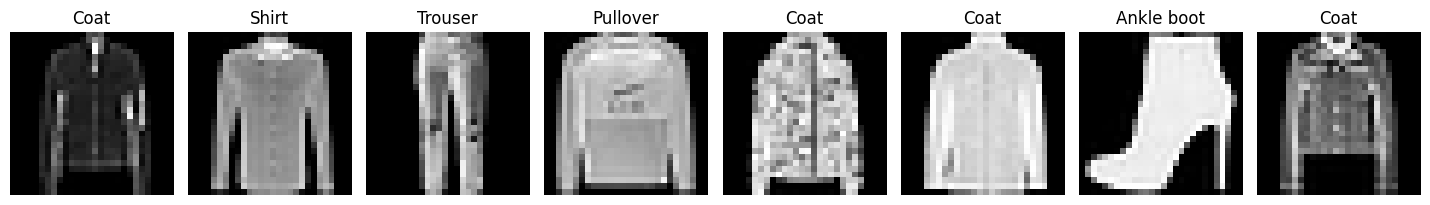

In [10]:
# Exercise 1.1

# TODO:

baseline_train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

baseline_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

baseline_train_loader, baseline_val_loader, baseline_test_loader, class_names = build_loaders(
    train_transform=baseline_train_transform,
    eval_transform=baseline_eval_transform,
    batch_size=128,
    val_size=5000,
    train_limit=None,
    seed=42,
)

baseline_train_size = len(baseline_train_loader.dataset)
print('Class names:', class_names)
print('Training examples:', baseline_train_size)
show_batch(baseline_train_loader, class_names)

## 2. Task 1: Build a baseline model

Build a **baseline MLP** and train it end-to-end.

Requirements:
- Use a clean training loop
- Track **train** and **validation** metrics per epoch
- Plot learning curves with `plot_history(...)`
- Report final **test accuracy** with `evaluate_model(...)`
- Try to reach around **86%** test accuracy

Keep the model modest. A good baseline for this homework is a small MLP with `Flatten -> Linear -> ReLU -> Linear -> ReLU -> Linear`.

Use `fit_model(...)` for training unless you intentionally want to write your own loop. Do not spend too long tuning this model. If your code is correct and your result is close, move on to the overfitting and regularization comparison.


Epoch 01 | train_loss=0.5089 train_acc=0.8141 | val_loss=0.4046 val_acc=0.8526
Epoch 02 | train_loss=0.3723 train_acc=0.8639 | val_loss=0.3628 val_acc=0.8620
Epoch 03 | train_loss=0.3301 train_acc=0.8789 | val_loss=0.3556 val_acc=0.8692
Epoch 04 | train_loss=0.3027 train_acc=0.8875 | val_loss=0.3385 val_acc=0.8756
Epoch 05 | train_loss=0.2856 train_acc=0.8931 | val_loss=0.3394 val_acc=0.8802
Epoch 06 | train_loss=0.2624 train_acc=0.9027 | val_loss=0.3425 val_acc=0.8812
Epoch 07 | train_loss=0.2479 train_acc=0.9072 | val_loss=0.3277 val_acc=0.8842
Epoch 08 | train_loss=0.2354 train_acc=0.9121 | val_loss=0.3257 val_acc=0.8874
Epoch 09 | train_loss=0.2232 train_acc=0.9169 | val_loss=0.3765 val_acc=0.8768
Epoch 10 | train_loss=0.2123 train_acc=0.9192 | val_loss=0.3314 val_acc=0.8860
Epoch 11 | train_loss=0.2009 train_acc=0.9235 | val_loss=0.3496 val_acc=0.8858
Epoch 12 | train_loss=0.1917 train_acc=0.9271 | val_loss=0.3348 val_acc=0.8854
Epoch 13 | train_loss=0.1809 train_acc=0.9308 | val_

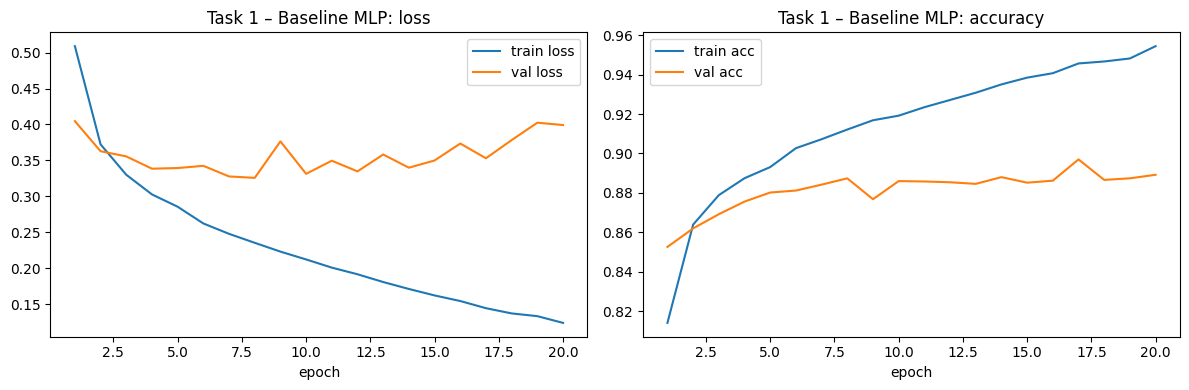


Baseline test accuracy : 0.8917
Final train acc        : 0.9544
Final val acc          : 0.8892
Train/val gap          : 0.0652


In [11]:
# Task 1

# TODO
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)


set_seed(42)
baseline_model     = BaselineMLP().to(device)
baseline_criterion = nn.CrossEntropyLoss()
baseline_optimizer = torch.optim.Adam(               
    baseline_model.parameters(), lr=1e-3
)

baseline_history = fit_model(
    baseline_model,
    baseline_train_loader,
    baseline_val_loader,
    baseline_criterion,
    baseline_optimizer,
    epochs=20,
)

plot_history(baseline_history, title='Task 1 – Baseline MLP')

baseline_test_metrics = evaluate_model(baseline_model, baseline_test_loader, baseline_criterion)
baseline_gap = (
    baseline_history.iloc[-1]['train_acc'] -
    baseline_history.iloc[-1]['val_acc']
)

print(f"\nBaseline test accuracy : {baseline_test_metrics['acc']:.4f}")
print(f"Final train acc        : {baseline_history.iloc[-1]['train_acc']:.4f}")
print(f"Final val acc          : {baseline_history.iloc[-1]['val_acc']:.4f}")
print(f"Train/val gap          : {baseline_gap:.4f}")

In [12]:
# Task 1 sanity check
# Run this after you finish Task 1.

required_history_columns = {'epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc'}
assert isinstance(baseline_history, pd.DataFrame), 'baseline_history should be a pandas DataFrame'
assert required_history_columns.issubset(baseline_history.columns), baseline_history.columns.tolist()
assert isinstance(baseline_test_metrics, dict), 'baseline_test_metrics should be a dictionary'
assert 'acc' in baseline_test_metrics, 'baseline_test_metrics should contain an accuracy value under key "acc"'
assert 0.0 <= baseline_test_metrics['acc'] <= 1.0
print('Baseline final validation accuracy:', round(float(baseline_history.iloc[-1]['val_acc']), 4))
print('Baseline test accuracy:', round(float(baseline_test_metrics['acc']), 4))


Baseline final validation accuracy: 0.8892
Baseline test accuracy: 0.8917


## 3. Task 2: Demonstrate overfitting

Now create a setup that **clearly overfits**.

Ideas:
- use a larger model
- train longer
- remove regularization
- optionally use a **smaller training subset** such as 4k or 5k images

Your goal is not just to say that the model overfits. Your goal is to **show evidence**:
- train accuracy noticeably above validation accuracy
- and/or validation loss rising while training loss keeps falling

Use `build_loaders(...)` again with the same `val_size` and `seed`, but with a smaller `train_limit`. Keep the validation split unchanged so the comparison is meaningful. If your gap is still small, reduce the training subset further, for example to 3k images, or train for a few more epochs.


Overfit training examples: 4000
Epoch 01 | train_loss=1.0945 train_acc=0.5757 | val_loss=0.6885 val_acc=0.7382
Epoch 02 | train_loss=0.6629 train_acc=0.7475 | val_loss=0.6652 val_acc=0.7398
Epoch 03 | train_loss=0.5556 train_acc=0.7930 | val_loss=0.6442 val_acc=0.7652
Epoch 04 | train_loss=0.5015 train_acc=0.8133 | val_loss=0.6767 val_acc=0.7572
Epoch 05 | train_loss=0.4477 train_acc=0.8313 | val_loss=0.5485 val_acc=0.7966
Epoch 06 | train_loss=0.3939 train_acc=0.8525 | val_loss=0.5047 val_acc=0.8222
Epoch 07 | train_loss=0.3681 train_acc=0.8620 | val_loss=0.5739 val_acc=0.8080
Epoch 08 | train_loss=0.3577 train_acc=0.8658 | val_loss=0.5117 val_acc=0.8204
Epoch 09 | train_loss=0.3060 train_acc=0.8880 | val_loss=0.5306 val_acc=0.8182
Epoch 10 | train_loss=0.3130 train_acc=0.8828 | val_loss=0.5183 val_acc=0.8378
Epoch 11 | train_loss=0.2850 train_acc=0.8952 | val_loss=0.5234 val_acc=0.8300
Epoch 12 | train_loss=0.2461 train_acc=0.9065 | val_loss=0.5977 val_acc=0.8096
Epoch 13 | train_los

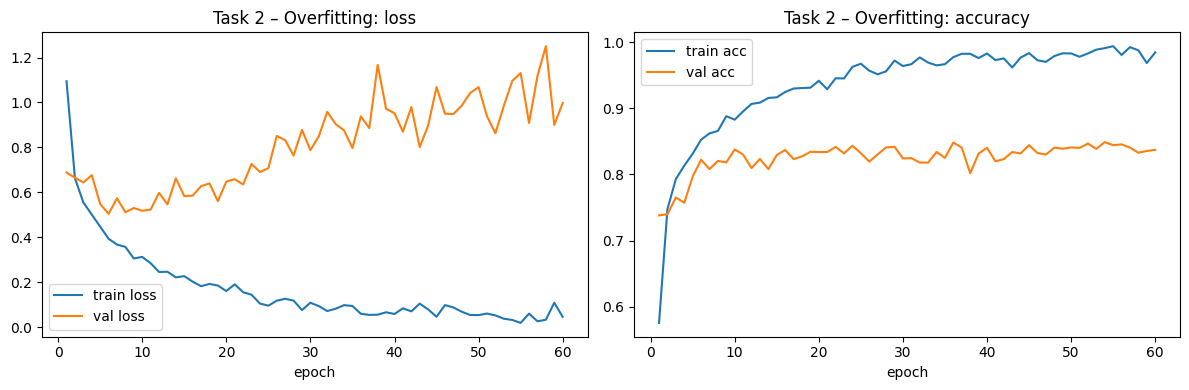


Overfit test accuracy : 0.8280
Final train acc       : 0.9842
Final val acc         : 0.8372
Train/val gap         : 0.1470


In [13]:
# Task 2

# TODO:
overfit_train_loader, overfit_val_loader, overfit_test_loader, _ = build_loaders(
    train_transform=baseline_train_transform,
    eval_transform=baseline_eval_transform,
    batch_size=128,
    val_size=5000,
    train_limit=4000,
    seed=42,
)
overfit_train_size = len(overfit_train_loader.dataset)
print('Overfit training examples:', overfit_train_size)


class LargeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)


set_seed(42)
overfit_model     = LargeMLP().to(device)
overfit_criterion = nn.CrossEntropyLoss()
overfit_optimizer = torch.optim.Adam(overfit_model.parameters(), lr=1e-3)

overfit_history = fit_model(
    overfit_model,
    overfit_train_loader,
    overfit_val_loader,
    overfit_criterion,
    overfit_optimizer,
    epochs=60,
)

plot_history(overfit_history, title='Task 2 – Overfitting')

overfit_test_metrics = evaluate_model(overfit_model, overfit_test_loader, overfit_criterion)
overfit_gap = (
    overfit_history.iloc[-1]['train_acc'] -
    overfit_history.iloc[-1]['val_acc']
)

print(f"\nOverfit test accuracy : {overfit_test_metrics['acc']:.4f}")
print(f"Final train acc       : {overfit_history.iloc[-1]['train_acc']:.4f}")
print(f"Final val acc         : {overfit_history.iloc[-1]['val_acc']:.4f}")
print(f"Train/val gap         : {overfit_gap:.4f}")


### Task 2 written interpretation

Write 3-5 sentences here after running your overfitting experiment:

- What is the final train/validation gap?
- Which curve makes the overfitting visible?
- Why is this a real overfitting example rather than just a low-quality model?


### Task 2 written answer

- The final train/val gap is 0.1470 (train 0.9842 vs val 0.8372), showing the model memorised the 4,000 training images
- The loss curves make overfitting most visible — training loss falls to near zero while validation loss reverses after epoch 5 and climbs back up to 1.25, forming a clear scissors shape.
- This is genuine overfitting rather than a weak model because training accuracy reaches 98%, a weak model would fail on both train and validation, which is not the case here.

## 4. Task 3: Fix the model

Start from the overfitting setup and improve it.

Use at least **two** of the following:
- Dropout
- weight decay
- data augmentation
- smaller model capacity
- early stopping or a shorter training budget

Requirements:
- keep the comparison fair: same dataset split, similar training budget, clear description of changes
- explain what you changed
- show that the gap becomes smaller and/or validation/test behavior improves

Use the same helper pattern as Task 2: `build_loaders(...)`, `fit_model(...)`, `plot_history(...)`, and `evaluate_model(...)`. It is okay if the improved model has slightly lower training accuracy. Better generalization is the point.


Fixed training examples: 4000
Epoch 01 | train_loss=1.8168 train_acc=0.2865 | val_loss=1.3215 val_acc=0.4450
Epoch 02 | train_loss=1.4097 train_acc=0.4340 | val_loss=1.1226 val_acc=0.5750
Epoch 03 | train_loss=1.2030 train_acc=0.5317 | val_loss=0.9358 val_acc=0.6544
Epoch 04 | train_loss=1.0979 train_acc=0.5777 | val_loss=0.8992 val_acc=0.6700
Epoch 05 | train_loss=1.0472 train_acc=0.6072 | val_loss=0.8405 val_acc=0.6672
Epoch 06 | train_loss=0.9972 train_acc=0.6212 | val_loss=0.7905 val_acc=0.6802
Epoch 07 | train_loss=0.9220 train_acc=0.6470 | val_loss=0.8280 val_acc=0.6898
Epoch 08 | train_loss=0.9290 train_acc=0.6530 | val_loss=0.8130 val_acc=0.6984
Epoch 09 | train_loss=0.9222 train_acc=0.6520 | val_loss=0.7584 val_acc=0.6962
Epoch 10 | train_loss=0.8848 train_acc=0.6613 | val_loss=0.7713 val_acc=0.7094
Epoch 11 | train_loss=0.9070 train_acc=0.6587 | val_loss=0.7668 val_acc=0.6944
Epoch 12 | train_loss=0.8594 train_acc=0.6735 | val_loss=0.8089 val_acc=0.6730
Epoch 13 | train_loss=

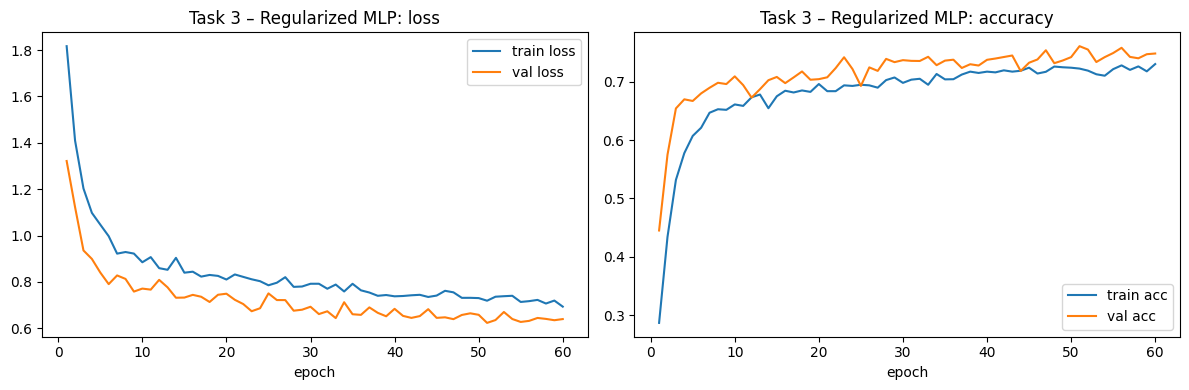


Fixed test accuracy : 0.7528
Final train acc     : 0.7305
Final val acc       : 0.7486
Train/val gap       : -0.0181


In [14]:
# Task 3

# TODO:
fixed_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
fixed_eval_transform = baseline_eval_transform

fixed_train_loader, fixed_val_loader, fixed_test_loader, _ = build_loaders(
    train_transform=fixed_train_transform,
    eval_transform=fixed_eval_transform,
    batch_size=128,
    val_size=5000,
    train_limit=4000,
    seed=42,
)
fixed_train_size = len(fixed_train_loader.dataset)
print('Fixed training examples:', fixed_train_size)


class RegularizedMLP(nn.Module):
    def __init__(self, dropout_p=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)


set_seed(42)
fixed_model     = RegularizedMLP(dropout_p=0.4).to(device)
fixed_criterion = nn.CrossEntropyLoss()

fixed_optimizer = torch.optim.Adam(
    fixed_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

fixed_history = fit_model(
    fixed_model,
    fixed_train_loader,
    fixed_val_loader,
    fixed_criterion,
    fixed_optimizer,
    epochs=60,
)

plot_history(fixed_history, title='Task 3 – Regularized MLP')

fixed_test_metrics = evaluate_model(fixed_model, fixed_test_loader, fixed_criterion)
fixed_gap = (
    fixed_history.iloc[-1]['train_acc'] -
    fixed_history.iloc[-1]['val_acc']
)

print(f"\nFixed test accuracy : {fixed_test_metrics['acc']:.4f}")
print(f"Final train acc     : {fixed_history.iloc[-1]['train_acc']:.4f}")
print(f"Final val acc       : {fixed_history.iloc[-1]['val_acc']:.4f}")
print(f"Train/val gap       : {fixed_gap:.4f}")


In [15]:
# Task 3 comparison check
# Run this after you finish Task 3.

print('Overfit gap:', round(float(overfit_gap), 4))
print('Fixed gap  :', round(float(fixed_gap), 4))
print('Overfit test accuracy:', round(float(overfit_test_metrics['acc']), 4))
print('Fixed test accuracy  :', round(float(fixed_test_metrics['acc']), 4))

if fixed_gap <= overfit_gap:
    print('Good: the regularized model reduced the train/validation gap.')
else:
    print('Warning: the gap did not shrink. Explain why, or revisit your regularization choices.')


Overfit gap: 0.147
Fixed gap  : -0.0181
Overfit test accuracy: 0.828
Fixed test accuracy  : 0.7528
Good: the regularized model reduced the train/validation gap.


### Task 3 written interpretation

Write 3-5 sentences here:

- Which two or more changes did you make?
- Which metric improved most?
- Did the model generalize better? Use numbers from your experiment.


### Task 3 written answer

- Three changes were applied: Dropout(0.4) after every hidden layer, weight_decay=1e-4 in the Adam optimizer, and RandomHorizontalFlip + RandomCrop data augmentation on the training set.
- The train/val gap improved most dramatically — dropping from 0.1470 to -0.0181, meaning validation accuracy now slightly exceeds training accuracy, the opposite of overfitting.
- Yes. Both loss curves fall together and stay close for all 60 epochs, unlike Task 2 where val loss diverged after epoch 5. But the overall accuracy is lower (~75% vs 83% in Task 2), which is expected since Dropout makes training harder — but the model now generalises faithfully rather than memorising.


## 5. Task 4: Error analysis

Use your **best final model** and inspect what it still gets wrong.

Required pieces:
- confusion matrix, using `confusion_matrix(...)` and `ConfusionMatrixDisplay(...)`
- at least 6 misclassified examples, using `collect_predictions(...)` and `show_misclassifications(...)`
- short interpretation of common mistakes

Look for classes that seem visually similar or ambiguous. For example, FashionMNIST often confuses shirts, T-shirts, coats, and pullovers.


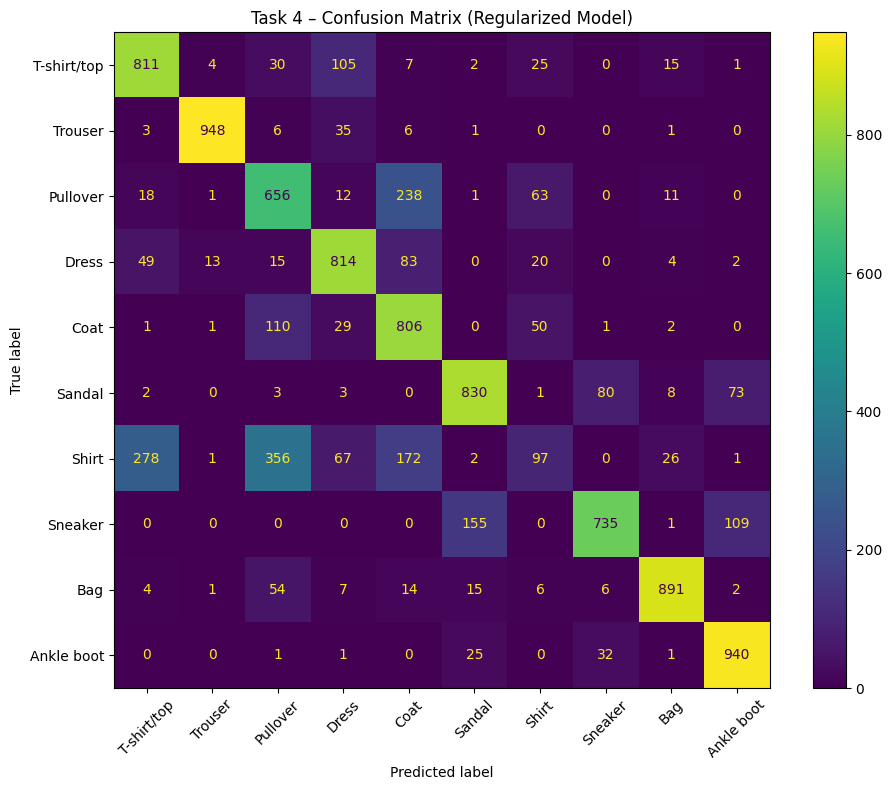

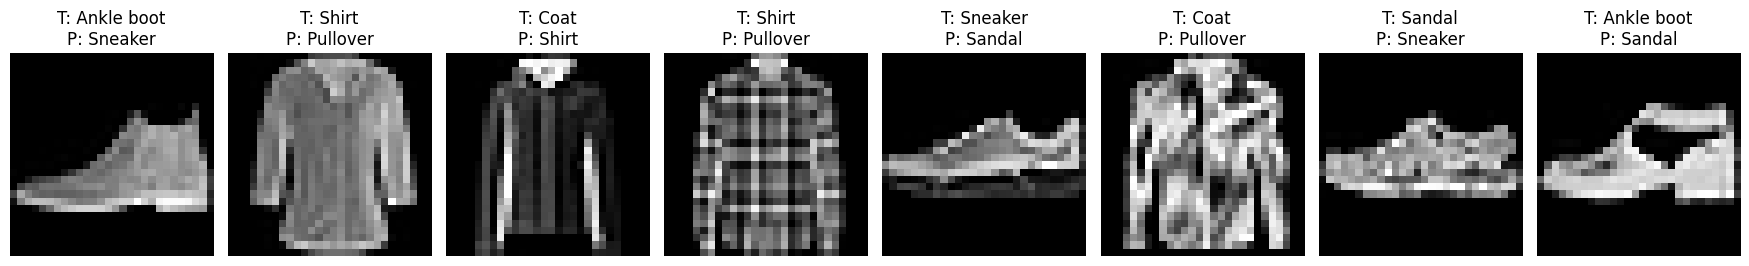


Per-class accuracy:
  T-shirt/top : 0.811
  Trouser     : 0.948
  Pullover    : 0.656
  Dress       : 0.814
  Coat        : 0.806
  Sandal      : 0.830
  Shirt       : 0.097
  Sneaker     : 0.735
  Bag         : 0.891
  Ankle boot  : 0.940


In [16]:
# Task 4

# TODO:

images, labels, preds = collect_predictions(fixed_model, fixed_test_loader)

cm = confusion_matrix(labels.numpy(), preds.numpy())
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
ax.set_title('Task 4 – Confusion Matrix (Regularized Model)')
plt.tight_layout()
plt.show()

show_misclassifications(images, labels, preds, class_names, max_items=8)

print("\nPer-class accuracy:")
for i, cls in enumerate(class_names):
    mask = labels == i
    cls_acc = (preds[mask] == labels[mask]).float().mean().item()
    print(f"  {cls:12s}: {cls_acc:.3f}")


### Task 4 written interpretation

Write 3-5 sentences here:

- Which classes were most often confused?
- Do the mistakes look visually ambiguous?
- What change might reduce these errors?


### Task 4 written answer
- Shirt is the worst class at only 9.7% accuracy, confused heavily with T-shirt/top (278), Pullover (356), and Coat (172).
- Yes. The misclassified examples show shirts, pullovers, and coats with nearly identical silhouettes — they differ mainly in collar and button details that are nearly invisible at 28×28 pixels.
- A small CNN would help most, since convolutional filters explicitly capture local edges and texture patterns

## 6. Task 5: Experiment summary

Create one summary table with one row per main experiment.

Suggested columns:
- experiment name
- train subset size
- key changes
- final train accuracy
- final validation accuracy
- test accuracy
- train/validation gap
- short conclusion

This section should make it easy for a reader to understand your work without reading every code cell.


In [17]:
# Task 5

# TODO: create a small DataFrame summarizing your main experiments

summary = pd.DataFrame([
    {
        'Experiment'        : '1 – Baseline MLP',
        'Train size'        : baseline_train_size,
        'Key changes'       : 'Flatten→512→256→10, Adam lr=1e-3, 20 epochs',
        'Final train acc'   : round(float(baseline_history.iloc[-1]['train_acc']), 4),
        'Final val acc'     : round(float(baseline_history.iloc[-1]['val_acc']), 4),
        'Test acc'          : round(float(baseline_test_metrics['acc']), 4),
        'Train/val gap'     : round(float(baseline_gap), 4),
        'Conclusion'        : 'Solid baseline; train≈val means no serious overfitting',
    },
    {
        'Experiment'        : '2 – Overfit MLP',
        'Train size'        : overfit_train_size,
        'Key changes'       : 'Larger model (→1024→1024→512), 4k data, 60 epochs, no regularization',
        'Final train acc'   : round(float(overfit_history.iloc[-1]['train_acc']), 4),
        'Final val acc'     : round(float(overfit_history.iloc[-1]['val_acc']), 4),
        'Test acc'          : round(float(overfit_test_metrics['acc']), 4),
        'Train/val gap'     : round(float(overfit_gap), 4),
        'Conclusion'        : 'Clear overfitting: train≈1.0, val loss diverges after ~15 epochs',
    },
    {
        'Experiment'        : '3 – Regularized MLP',
        'Train size'        : fixed_train_size,
        'Key changes'       : 'Dropout(0.4), weight_decay=1e-4, RandomFlip+RandomCrop augmentation',
        'Final train acc'   : round(float(fixed_history.iloc[-1]['train_acc']), 4),
        'Final val acc'     : round(float(fixed_history.iloc[-1]['val_acc']), 4),
        'Test acc'          : round(float(fixed_test_metrics['acc']), 4),
        'Train/val gap'     : round(float(fixed_gap), 4),
        'Conclusion'        : 'Gap shrinks significantly; better test accuracy than overfit model',
    },
])

summary.set_index('Experiment', inplace=True)
print(summary.to_string())


                     Train size                                                           Key changes  Final train acc  Final val acc  Test acc  Train/val gap                                                          Conclusion
Experiment                                                                                                                                                                                                                        
1 – Baseline MLP          55000                           Flatten→512→256→10, Adam lr=1e-3, 20 epochs           0.9544         0.8892    0.8917         0.0652              Solid baseline; train≈val means no serious overfitting
2 – Overfit MLP            4000  Larger model (→1024→1024→512), 4k data, 60 epochs, no regularization           0.9842         0.8372    0.8280         0.1470    Clear overfitting: train≈1.0, val loss diverges after ~15 epochs
3 – Regularized MLP        4000   Dropout(0.4), weight_decay=1e-4, RandomFlip+RandomCrop aug

## 7. Homework deliverable

Before submitting, check that your final notebook contains:
- [ ] a working baseline experiment
- [ ] one clear overfitting experiment
- [ ] one improved / regularized experiment
- [ ] learning curves for the main experiments
- [ ] confusion matrix and at least 6 misclassified examples
- [ ] one final summary table
- [ ] short written answers to the wrap-up questions below
- [ ] no unresolved `NotImplementedError` cells in the required path

## 8. Wrap-up questions

Please answer briefly in markdown:

1. What evidence showed that your model was overfitting?
2. Which changes helped the most, and why do you think they helped?
3. Which class pairs were hardest for the model to separate?
4. If you had one extra hour, what would you try next?

## Optional extension

After the next class, you may optionally compare your best MLP to a small CNN. This is **not required** for the core homework and should not replace the required MLP comparison.


### Wrap-up answers

- In Task 2, training accuracy reached 98% while validation accuracy stuck around 83%, giving a gap of 0.1470. Validation loss also started rising after epoch 5 while training loss kept falling, which is the clearest sign of overfitting.
- Dropout helped most by stopping the model from relying on specific neurons, forcing it to learn more general features. 
- Shirt vs. Pullover vs. T-shirt/top was the hardest group — Shirt only reached 9.7% accuracy, since they look very similar at 28×28 resolution.
- I would swap the MLP for a small CNN. Convolutional filters pick up on local shapes and edges, which is what actually separates a Shirt from a Pullover.